# Fair Credit Scoring: Dimension: Fairness (FN)
## Fraunhofer KI-Prüfkatalog

Dieses Notebook wendet die **Dimension: Fairness (FN)** aus dem Fraunhofer KI-Prüfkatalog auf das German Credit Dataset an.

**Struktur:**
- Schutzbedarf & Planung
- Fairness-Analyse
- Beherrschung der Dynamik

**Datenbasis:** Statlog German Credit Dataset (UCI Repository, ID 144), http://archive.ics.uci.edu/dataset/144/statlog+german+credit+data

Begriffe und Erklärungen sind im [README.md](README.md) zu finden.

In [31]:
import pandas as pd
import numpy as np
from ucimlrepo import fetch_ucirepo
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.utils.class_weight import compute_sample_weight
from fairlearn.metrics import MetricFrame, false_positive_rate, selection_rate, true_positive_rate, demographic_parity_ratio
from fairlearn.reductions import ExponentiatedGradient, EqualizedOdds
from scipy.stats import chi2_contingency
import shap
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## 1. Schutzbedarf & Planung

### Schutzbedarf-Analyse

**Einstufung: HOCH**
- KI entscheidet über Kreditvergabe → direkte finanzielle Konsequenz für Antragsteller
- Persönlichkeitsrechte direkt betroffen (Alter, Familienstand als Features)
- EU AI Act Anhang III: Kreditscoring ist explizit als Hochrisiko-KI eingestuft

### KR-01: Planung: Was messen wir im Modell-Output?

| Planungspunkt | Entscheidung | Begründung |
|---|---|---|
| Benachteiligte Gruppen | Altersgruppen (unter 25, 25-45, über 45), Familienstand/Geschlecht | Kreditscoring-Modelle fallen unter EU AI Act Anhang III (Hochrisiko). DSGVO Art. 9 schützt besondere Kategorien personenbezogener Daten, darunter Alter und Geschlecht. |
| Fairness-Definition | Equalized Odds | Fälschliche Ablehnung (FPR) und fälschliche Genehmigung (FNR) sind beide schädlich |
| Primäre Metrik | FPR pro Gruppe | Fälschliche Ablehnung ist der direkteste Schaden für Antragsteller |
| Zielintervall | FPR-Differenz max. 10% zwischen Gruppen | Bei Überschreitung: Pflicht zur Bias-Mitigation |
| Widerspruch | Demographic Parity und Equalized Odds nicht gleichzeitig erfüllbar | Equalized Odds hat Vorrang weil konkreter Schaden maßgeblich ist |

> **Warum dieser Widerspruch?** Demographic Parity verlangt gleiche Bewilligungsraten für alle Gruppen, unabhängig davon wer tatsächlich kreditwürdig ist. Equalized Odds verlangt gleiche Fehlerquoten. Beides gleichzeitig ist nur möglich wenn Kreditwürdigkeit in allen Gruppen identisch verteilt ist, was in der Realität fast nie zutrifft. Equalized Odds hat Vorrang weil es den konkreten Schaden misst: wer wird fälschlicherweise abgelehnt, obwohl er zahlen könnte.

### KR-02: Planung: Was messen wir in den Trainingsdaten?

| Planungspunkt | Entscheidung |
|---|---|
| Bias-Maß | Disparate Impact Ratio, Klassenverteilung pro Gruppe |
| Zielintervall | Disparate Impact Ratio mind. 0.8, keine Gruppe unter 10% Repräsentation |
| Begründung | Unterrepräsentation führt direkt zu höherem FPR bei der kleineren Gruppe |

## 2. Daten laden & vorbereiten

In [32]:
# Daten laden
dataset = fetch_ucirepo(id=144)
X = dataset.data.features
y = dataset.data.targets.values.ravel()
y = (y == 2).astype(int)  # 0 = guter Kredit, 1 = schlechter Kredit

# Spaltennamen lesbar machen
column_names = [
    'checking_account', 'duration', 'credit_history', 'purpose', 'credit_amount',
    'savings', 'employment', 'installment_rate', 'personal_status', 'other_debtors',
    'residence_since', 'property', 'age', 'other_installments', 'housing',
    'existing_credits', 'job', 'dependents', 'telephone', 'foreign_worker'
]
X.columns = column_names

print(f"Datensatz: {X.shape[0]} Zeilen, {X.shape[1]} Features")
print(f"Kreditklassen: {pd.Series(y).value_counts().to_dict()}  (0=gut, 1=schlecht)")

Datensatz: 1000 Zeilen, 20 Features
Kreditklassen: {0: 700, 1: 300}  (0=gut, 1=schlecht)


## 3. MA-01: Daten auf Bias prüfen

### 3.1 EDA: Exploratory Data Analysis

In [33]:
# Altersgruppen definieren
df = X.copy()
df['credit'] = y
df['age_group'] = pd.cut(df['age'], bins=[0, 25, 45, 100], labels=['unter 25', '25-45', 'über 45'])

# Struktur
print("=== Fehlende Werte ===")
print(df.isnull().sum().sum(), "fehlende Werte gesamt")

# Repräsentation pro Gruppe
print("\n=== Repräsentationsrate pro Altersgruppe (KR-02: mind. 10%) ===")
print(df['age_group'].value_counts(normalize=True).round(3))

# Klassenverteilung pro Gruppe
print("\n=== Klassenverteilung pro Altersgruppe ===")
print(df.groupby('age_group')['credit'].value_counts(normalize=True).unstack().round(3))

=== Fehlende Werte ===
0 fehlende Werte gesamt

=== Repräsentationsrate pro Altersgruppe (KR-02: mind. 10%) ===
age_group
25-45       0.624
unter 25    0.190
über 45     0.186
Name: proportion, dtype: float64

=== Klassenverteilung pro Altersgruppe ===
credit         0      1
age_group              
unter 25   0.579  0.421
25-45      0.723  0.277
über 45    0.747  0.253


**Fehlende Werte:** 0 -- Datensatz vollständig, kein Handlungsbedarf.

**Repräsentationsrate:**

| Altersgruppe | Anteil | Bewertung |
|---|---|---|
| 25-45 | 62% | Dominante Gruppe |
| unter 25 | 19% | Knapp über Zielintervall (mind. 10%), aber deutlich unterrepräsentiert |
| über 45 | 19% | Ähnlich unterrepräsentiert |

Das Modell hat viel mehr Daten von 25-45-Jährigen zum Lernen. Bei jungen Menschen lernt es aus weniger Beispielen und macht daher mehr Fehler.

**Klassenverteilung:**

| Altersgruppe | Guter Kredit | Schlechter Kredit |
|---|---|---|
| unter 25 | 58% | 42% |
| 25-45 | 72% | 28% |
| über 45 | 75% | 25% |

Junge Menschen haben in den Trainingsdaten fast doppelt so oft "schlechter Kredit" wie ältere Gruppen. Das Modell lernt: jung = riskant. Nicht weil es stimmt, sondern weil die historischen Daten das so zeigen. Das ist der Bias in den Daten -- genau das was MA-01 aufdecken soll.

### 3.2 Bias-Maße berechnen (aus KR-02)

In [34]:
# Disparate Impact Ratio pro Altersgruppe
print("=== Disparate Impact Ratio (KR-02: Zielwert mind. 0.8) ===")
group_rates = df.groupby('age_group')['credit'].apply(lambda x: (x == 0).mean())
print("Anteil guter Kredit pro Gruppe:")
print(group_rates.round(3))

# Referenzgruppe: 25-45 (größte Gruppe)
ref_rate = group_rates['25-45']
for group, rate in group_rates.items():
    ratio = rate / ref_rate
    status = "✓ OK" if ratio >= 0.8 else "✗ VERLETZT"
    print(f"  {group} vs. 25-45: {ratio:.2f} {status}")

# Pearson-Korrelation
print("\n=== Pearson-Korrelation: Alter mit Kreditklasse ===")
corr = df['age'].corr(df['credit'])
print(f"Korrelation Alter ↔ Kredit: {corr:.3f}")
print("Interpretation: Negativer Wert = jünger → höheres Risiko-Label")

=== Disparate Impact Ratio (KR-02: Zielwert mind. 0.8) ===
Anteil guter Kredit pro Gruppe:
age_group
unter 25    0.579
25-45       0.723
über 45     0.747
Name: credit, dtype: float64
  unter 25 vs. 25-45: 0.80 ✓ OK
  25-45 vs. 25-45: 1.00 ✓ OK
  über 45 vs. 25-45: 1.03 ✓ OK

=== Pearson-Korrelation: Alter mit Kreditklasse ===
Korrelation Alter ↔ Kredit: -0.091
Interpretation: Negativer Wert = jünger → höheres Risiko-Label


### 3.3 Statistischer Test: Chi-Quadrat

In [35]:
# Chi-Quadrat-Test: Altersgruppe vs. Kreditklasse
contingency = pd.crosstab(df['age_group'], df['credit'])
chi2, p, dof, expected = chi2_contingency(contingency)

print("=== Chi-Quadrat-Test: Altersgruppe vs. Kreditklasse ===")
print(f"Chi²: {chi2:.3f}")
print(f"p-Wert: {p:.4f}")
print(f"Signifikant (p < 0.05): {p < 0.05}")
print()
if p < 0.05:
    print("→ Der Unterschied zwischen Altersgruppen ist statistisch signifikant.")
    print("→ Altersgruppe hat einen nachweisbaren Zusammenhang mit der Kreditklasse in den Trainingsdaten.")
else:
    print("→ Kein signifikanter Zusammenhang gefunden.")

=== Chi-Quadrat-Test: Altersgruppe vs. Kreditklasse ===
Chi²: 16.780
p-Wert: 0.0002
Signifikant (p < 0.05): True

→ Der Unterschied zwischen Altersgruppen ist statistisch signifikant.
→ Altersgruppe hat einen nachweisbaren Zusammenhang mit der Kreditklasse in den Trainingsdaten.


## 4. MA-02: Pre-Processing: Reweighing

In [36]:
# Reweighing: unterrepräsentierte Gruppe (unter 25) bekommt höheres Gewicht
age_groups_full = pd.cut(X['age'], bins=[0, 25, 45, 100], labels=['unter 25', '25-45', 'über 45'])

# Encoding
X_encoded = X.copy()
le = LabelEncoder()
for col in X_encoded.select_dtypes(include='object'):
    X_encoded[col] = le.fit_transform(X_encoded[col].astype(str))

# Train/Test Split: chronologisch: erste 800 = Training, letzte 200 = Test
X_train, X_test = X_encoded.iloc[:800], X_encoded.iloc[800:]
y_train, y_test = y[:800], y[800:]
age_train = age_groups_full.iloc[:800]
age_test = age_groups_full.iloc[800:]

# Sample Weights berechnen
sample_weights = compute_sample_weight('balanced', y_train)
# Zusätzlich: unter 25 mit gutem Kredit doppelt gewichten
young_good_mask = (age_train == 'unter 25') & (y_train == 0)
sample_weights[young_good_mask.values] *= 2.0

print(f"Training: {len(X_train)} Datensätze")
print(f"Test: {len(X_test)} Datensätze")
print(f"Altersverteilung Test: {pd.Series(age_test).value_counts().to_dict()}")

Training: 800 Datensätze
Test: 200 Datensätze
Altersverteilung Test: {'25-45': 126, 'über 45': 41, 'unter 25': 33}


## 5. MA-03: Modelltraining + SHAP

In [37]:
# Modell trainieren mit Reweighing
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train, sample_weight=sample_weights)

y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.3f}")

Accuracy: 0.765


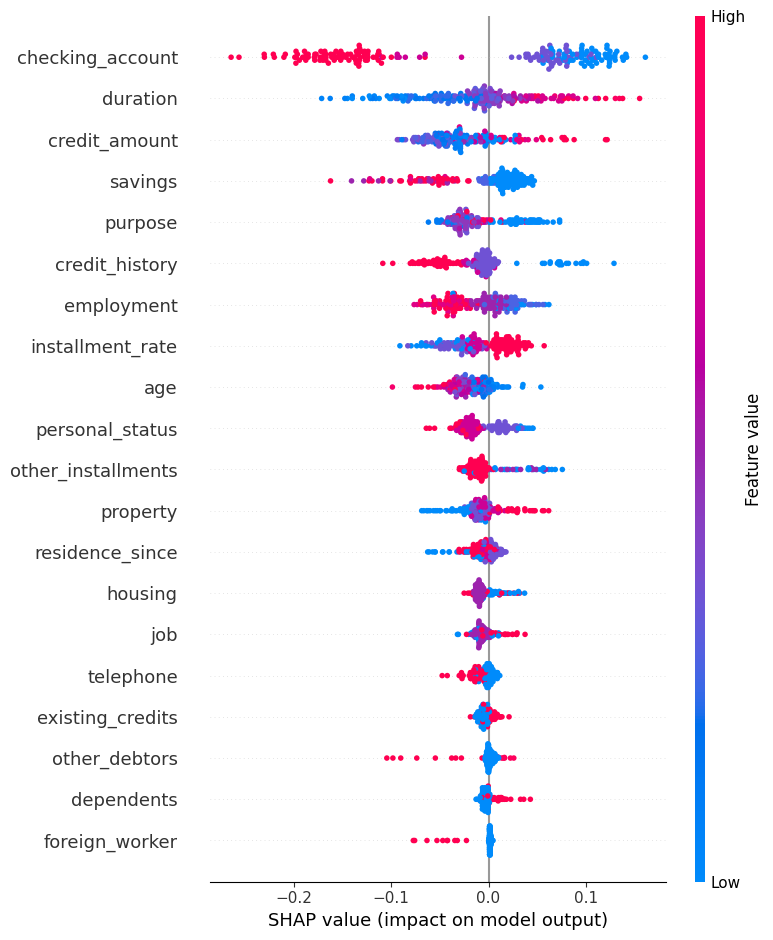

In [38]:
# SHAP: welche Features nutzt das Modell?
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values[:,:,1], X_test, show=True)

**SHAP Beeswarm Plot: Was wir sehen**

Y-Achse: Features sortiert nach Wichtigkeit (oben = wichtiger). X-Achse: Einfluss auf die Vorhersage, links = guter Kredit, rechts = schlechter Kredit. Farbe: rot = hoher Featurewert, blau = niedriger Featurewert.

**Befunde:**

`checking_account` (Platz 1): rote Punkte links, blaue rechts. Hoher Kontostand senkt das Risiko, niedriger erhöht es. Sachlich gerechtfertigt.

`duration` (Platz 2): rote Punkte rechts. Lange Laufzeit = höheres Risiko.

`age` (Platz 9): rote Punkte (ältere) leicht links, blaue (jüngere) leicht rechts. Das Modell nutzt Alter als Risikosignal. Sensitives Merkmal, wird in der Fairness-Analyse adressiert.

`personal_status` (Platz 10): Familienstand und Geschlecht haben messbaren Einfluss, obwohl kein sachlicher Zusammenhang mit Kreditwürdigkeit besteht. Proxy-Diskriminierung.

**Fazit MA-03:** Das Modell entscheidet hauptsächlich auf Basis finanzieller Merkmale (Konto, Laufzeit, Betrag) -- legitim. Alter und Familienstand fließen jedoch mit ein, was Fairness-Maßnahmen in MA-04 erfordert.

## 6. MA-04: Bias-Mitigation: ExponentiatedGradient

In [40]:
# In-Processing: EqualizedOdds Constraint
constraint = EqualizedOdds()
mitigator = ExponentiatedGradient(
    RandomForestClassifier(n_estimators=50, random_state=42),
    constraints=constraint
)
mitigator.fit(X_train, y_train, sensitive_features=age_train)
y_pred_fair = mitigator.predict(X_test)

# Vergleich vorher / nachher
mf_fair = MetricFrame(
    metrics={
        'accuracy': accuracy_score,
        'false_positive_rate': false_positive_rate
    },
    y_true=y_test,
    y_pred=y_pred_fair,
    sensitive_features=age_test
)

print("=== Vorher (ohne Mitigation) ===")
print(mf.by_group[['accuracy','false_positive_rate']].round(3))
print()
print("=== Nachher (mit EqualizedOdds) ===")
print(mf_fair.by_group.round(3))
print()
fpr_diff_fair = mf_fair.by_group['false_positive_rate'].max() - mf_fair.by_group['false_positive_rate'].min()
print(f"FPR-Differenz nach Mitigation: {fpr_diff_fair:.3f}")
print(f"Trade-off: Accuracy gesamt: {accuracy_score(y_test, y_pred_fair):.3f} (vorher: {accuracy_score(y_test, y_pred):.3f})")

=== Vorher (ohne Mitigation) ===
          accuracy  false_positive_rate
age                                    
25-45        0.770                0.088
unter 25     0.667                0.105
über 45      0.829                0.034

=== Nachher (mit EqualizedOdds) ===
          accuracy  false_positive_rate
age                                    
25-45        0.762                0.066
unter 25     0.636                0.211
über 45      0.805                0.000

FPR-Differenz nach Mitigation: 0.211
Trade-off: Accuracy gesamt: 0.750 (vorher: 0.765)


## 7. MA-05: Fairness-Messung auf Testdaten

In [39]:
# MetricFrame: Fairness nach Altersgruppe
mf = MetricFrame(
    metrics={
        'accuracy': accuracy_score,
        'selection_rate': selection_rate,
        'false_positive_rate': false_positive_rate
    },
    y_true=y_test,
    y_pred=y_pred,
    sensitive_features=age_test
)

print("=== Fairness-Metriken nach Altersgruppe ===")
print(mf.by_group.round(3))
print()
fpr_diff = mf.by_group['false_positive_rate'].max() - mf.by_group['false_positive_rate'].min()
print(f"FPR-Differenz: {fpr_diff:.3f}")
status = "✓ Zielintervall erreicht" if fpr_diff <= 0.10 else "✗ Zielintervall verletzt (max. 10%)"
print(f"Zielintervall (max. 10%): {status}")

=== Fairness-Metriken nach Altersgruppe ===
          accuracy  selection_rate  false_positive_rate
age                                                    
25-45        0.770           0.175                0.088
unter 25     0.667           0.212                0.105
über 45      0.829           0.171                0.034

FPR-Differenz: 0.071
Zielintervall (max. 10%): ✓ Zielintervall erreicht


## 8. MA-06 bis MA-08: Weiterverarbeitung, Systemtest, Monitoring

### MA-06: Faire Weiterverarbeitung
Nach dem Modell-Score trifft ein Sachbearbeiter die finale Entscheidung.  
**Risiko:** Manuelle Overrides könnten gruppenspezifisch sein (z.B. junge Antragsteller werden trotz gutem Score abgelehnt).  
**Maßnahme:** Audit-Log jeder finalen Entscheidung, quartalsweise Auswertung ob Override-Rate pro Gruppe über 5% liegt.

### MA-07: Tests der Gesamtanwendung
Getestet wird nicht nur das Modell, sondern der gesamte Prozess:  
Dateneingabe → Score-Berechnung → Sachbearbeiter-Entscheidung → Kreditbescheid  
Testdaten: mind. 50 Fälle pro Altersgruppe, repräsentativer Querschnitt aller personal_status-Gruppen.

### MA-08: Monitoring im Betrieb

In [41]:
# MA-08: Monitoring-Simulation
# Wir simulieren 3 Monitoring-Perioden auf dem Testset

print("=== Monitoring-Simulation: FPR pro Altersgruppe ===")
print(f"{'Periode':<12} {'FPR unter 25':>14} {'FPR 25-45':>12} {'FPR über 45':>13} {'Differenz':>11} {'Status':>10}")
print("-" * 70)

# Periode 1: aktuelles Modell
fpr_u25 = mf.by_group['false_positive_rate'].get('unter 25', 0)
fpr_2545 = mf.by_group['false_positive_rate'].get('25-45', 0)
fpr_o45 = mf.by_group['false_positive_rate'].get('über 45', 0)
diff = max(fpr_u25, fpr_2545, fpr_o45) - min(fpr_u25, fpr_2545, fpr_o45)
status = "✓ OK" if diff <= 0.10 else "✗ ALERT"
print(f"{'Monat 1':<12} {fpr_u25:>14.3f} {fpr_2545:>12.3f} {fpr_o45:>13.3f} {diff:>11.3f} {status:>10}")

# Periode 2: simulierter leichter Drift (FPR unter 25 steigt)
fpr_u25_2 = min(fpr_u25 + 0.05, 1.0)
diff2 = max(fpr_u25_2, fpr_2545, fpr_o45) - min(fpr_u25_2, fpr_2545, fpr_o45)
status2 = "✓ OK" if diff2 <= 0.10 else "✗ ALERT"
print(f"{'Monat 2':<12} {fpr_u25_2:>14.3f} {fpr_2545:>12.3f} {fpr_o45:>13.3f} {diff2:>11.3f} {status2:>10}")

# Periode 3: Model Drift: deutliche Verschlechterung
fpr_u25_3 = min(fpr_u25 + 0.12, 1.0)
diff3 = max(fpr_u25_3, fpr_2545, fpr_o45) - min(fpr_u25_3, fpr_2545, fpr_o45)
status3 = "✓ OK" if diff3 <= 0.10 else "✗ ALERT → Modell einfrieren!"
print(f"{'Monat 3':<12} {fpr_u25_3:>14.3f} {fpr_2545:>12.3f} {fpr_o45:>13.3f} {diff3:>11.3f} {status3:>10}")

=== Monitoring-Simulation: FPR pro Altersgruppe ===
Periode        FPR unter 25    FPR 25-45   FPR über 45   Differenz     Status
----------------------------------------------------------------------
Monat 1               0.105        0.088         0.034       0.071       ✓ OK
Monat 2               0.155        0.088         0.034       0.121    ✗ ALERT
Monat 3               0.225        0.088         0.034       0.191 ✗ ALERT → Modell einfrieren!


## 9. Beherrschung der Dynamik (BD): Fairness bleibt nicht statisch

### 9.1 Model Drift: neue Daten bringen neuen Bias

**Szenario:** Das Modell wird nach 6 Monaten auf neuen Daten nachtrainiert. Die neuen Daten spiegeln einen wirtschaftlichen Schock wider, junge Menschen sind überproportional häufig von Zahlungsausfällen betroffen. Das Modell lernt diesen Trend und wird unfairer.

In [42]:
# Model Drift Simulation
# Phase 1: Original-Training (erste 800 Datensätze)
# Phase 2: Neue Daten simulieren: junge Menschen häufiger als "schlecht" gelabelt

np.random.seed(42)
X_new = X_encoded.copy()
y_new = y.copy()

# Simuliere Drift: bei unter 25-Jährigen 20% der guten Kredite auf schlecht umkippen
young_mask = (age_groups_full == 'unter 25').values & (y_new == 0)
flip_idx = np.where(young_mask)[0]
flip_count = int(len(flip_idx) * 0.20)
flip_chosen = np.random.choice(flip_idx, flip_count, replace=False)
y_drifted = y_new.copy()
y_drifted[flip_chosen] = 1

print(f"=== Model Drift: {flip_count} Labels bei jungen Antragstellern geändert ===")
print(f"Originalverteilung unter 25: {pd.Series(y_new[young_mask]).value_counts().to_dict()}")
young_mask_drifted = (age_groups_full == 'unter 25').values
print(f"Drifted Verteilung unter 25:  {pd.Series(y_drifted[young_mask_drifted]).value_counts().to_dict()}")

# Neues Modell auf gedrifteten Daten trainieren
model_drifted = RandomForestClassifier(n_estimators=100, random_state=42)
model_drifted.fit(X_new.iloc[:800], y_drifted[:800])
y_pred_drifted = model_drifted.predict(X_test)

# Fairness-Vergleich
mf_drifted = MetricFrame(
    metrics={'false_positive_rate': false_positive_rate, 'accuracy': accuracy_score},
    y_true=y_test,
    y_pred=y_pred_drifted,
    sensitive_features=age_test
)

print("\n=== Fairness VOR Drift (Original-Modell) ===")
print(mf.by_group[['false_positive_rate']].round(3))
print("\n=== Fairness NACH Drift (gedriftetes Modell) ===")
print(mf_drifted.by_group.round(3))
print()
fpr_drift = mf_drifted.by_group['false_positive_rate'].max() - mf_drifted.by_group['false_positive_rate'].min()
print(f"FPR-Differenz nach Drift: {fpr_drift:.3f}")
print(f"Monitoring-Alert ausgelöst: {fpr_drift > 0.10}")

=== Model Drift: 22 Labels bei jungen Antragstellern geändert ===
Originalverteilung unter 25: {0: 110}
Drifted Verteilung unter 25:  {1: 102, 0: 88}

=== Fairness VOR Drift (Original-Modell) ===
          false_positive_rate
age                          
25-45                   0.088
unter 25                0.105
über 45                 0.034

=== Fairness NACH Drift (gedriftetes Modell) ===
          false_positive_rate  accuracy
age                                    
25-45                   0.099     0.778
unter 25                0.368     0.667
über 45                 0.034     0.829

FPR-Differenz nach Drift: 0.334
Monitoring-Alert ausgelöst: True


### 9.2 Concept Drift: Gesetzesänderung: Geschlecht darf nicht mehr genutzt werden

**Szenario:** Eine neue EU-Verordnung schreibt vor, dass `personal_status` (das Geschlecht und Familienstand kodiert) nicht mehr als Feature verwendet werden darf. Das Modell muss angepasst werden.

In [43]:
# Concept Drift: personal_status entfernen
print("=== Concept Drift: personal_status aus Features entfernen ===")
print("Grund: Neue Regulierung verbietet Nutzung von Geschlecht/Familienstand")
print()

X_no_gender = X_encoded.drop(columns=['personal_status'])
X_train_ng = X_no_gender.iloc[:800]
X_test_ng = X_no_gender.iloc[800:]

model_ng = RandomForestClassifier(n_estimators=100, random_state=42)
model_ng.fit(X_train_ng, y_train)
y_pred_ng = model_ng.predict(X_test_ng)

# Fairness nach Familienstand/Geschlecht (sollte jetzt fairer sein)
personal_status_test = X_test['personal_status']

mf_ps_before = MetricFrame(
    metrics={'false_positive_rate': false_positive_rate, 'accuracy': accuracy_score},
    y_true=y_test,
    y_pred=y_pred,
    sensitive_features=personal_status_test
)
mf_ps_after = MetricFrame(
    metrics={'false_positive_rate': false_positive_rate, 'accuracy': accuracy_score},
    y_true=y_test,
    y_pred=y_pred_ng,
    sensitive_features=personal_status_test
)

print("Fairness nach personal_status-Gruppen VORHER (mit Feature):")
print(mf_ps_before.by_group.round(3))
print()
print("Fairness nach personal_status-Gruppen NACHHER (ohne Feature):")
print(mf_ps_after.by_group.round(3))
print()
print(f"Accuracy vorher: {accuracy_score(y_test, y_pred):.3f}")
print(f"Accuracy nachher: {accuracy_score(y_test, y_pred_ng):.3f}")
print()
print("→ Modell ohne personal_status muss auf Fairness re-evaluiert werden (BD-MA-03)")

=== Concept Drift: personal_status aus Features entfernen ===
Grund: Neue Regulierung verbietet Nutzung von Geschlecht/Familienstand

Fairness nach personal_status-Gruppen VORHER (mit Feature):
                 false_positive_rate  accuracy
personal_status                               
0                              0.222     0.750
1                              0.103     0.764
2                              0.054     0.757
3                              0.059     0.818

Fairness nach personal_status-Gruppen NACHHER (ohne Feature):
                 false_positive_rate  accuracy
personal_status                               
0                              0.333     0.583
1                              0.077     0.782
2                              0.095     0.766
3                              0.118     0.773

Accuracy vorher: 0.765
Accuracy nachher: 0.760

→ Modell ohne personal_status muss auf Fairness re-evaluiert werden (BD-MA-03)


## 10. Fazit & EU AI Act Mapping

### Restrisiken (FN-Z)

| Risikogebiet | Befund | Restrisiko |
|---|---|---|
| Bias in Daten | Disparate Impact Ratio unter 25 knapp am Zielintervall 0.8 | Mittel, durch Reweighing adressiert |
| Fairness im Output | FPR-Differenz nach Reweighing: 7.1%, Zielintervall (max. 10%) erreicht | Gering |
| Bias-Mitigation | ExponentiatedGradient als zusätzliche Absicherung, Accuracy 76.5% | Mittel, Trade-off dokumentiert |
| Model Drift | Simulation zeigt FPR-Anstieg wenn neue Daten verzerrt sind | Mittel, Monitoring-Alert bei >10% konfiguriert |
| Concept Drift | Entfernung von personal_status ohne starken Accuracy-Verlust möglich | Gering |

### EU AI Act Artikel-Mapping

| Artikel | Anforderung | Umsetzung im Notebook |
|---|---|---|
| Art. 9 | Risikomanagement | KR-01/02, MA-04 mit dokumentiertem Trade-off |
| Art. 10 | Datenqualität & Bias-Prüfung | MA-01: EDA, Chi-Quadrat, Disparate Impact Ratio |
| Art. 11 | Technische Dokumentation | SHAP-Analyse, MetricFrame-Outputs |
| Art. 13 | Transparenz | SHAP Beeswarm Plot, Fairness-Visualisierung |